In [ ]:
# Load in datasets

import pandas as pd
pre = "https://raw.githubusercontent.com/refbank/refbank-import/main/harmonized_data/"
datasets = ["boyce2024_interaction/", "eliav2023_semantic/", "hawkins2019_continual/", "hawkins2020_characterizing_cued/", "hawkins2021_respect/",
            "hawkins2023_frompartners/", "leung2024_scaffolding/",
            "mankewitz2025_function/"]

# Issues with "yoon2019_audience"

end = ["messages.csv", "trials.csv"]
lst_datasets = [[pre + dataset + end[0], pre + dataset + end[1]] for dataset in datasets]
lst_dfs = []

# Pre-process datasets
for dataset in lst_datasets:
  print(dataset[0], dataset[1])
  message_df = pd.read_csv(dataset[0])
  trials_df = pd.read_csv(dataset[1])

  result = pd.merge(message_df, trials_df, on="trial_id", how="left")
  cleaned_result = result[
      (result["role"] == "describer") &
      (result["text"].notna()) &
      (result["stage_num"] == 1)][["text", "rep_num"]].reset_index()
  lst_dfs.append(cleaned_result)

# Load in Hawkins 2020 Uncued
hawkins_uncued = pd.read_csv("https://raw.githubusercontent.com/refbank/refbank-import/main/import/hawkins2020_characterizing_uncued/segmented_data.csv")
hawkins_cleaned = hawkins_uncued[
      (hawkins_uncued["role"] == "describer") &
      (hawkins_uncued["text"].notna()) &
      (hawkins_uncued["stage_num"] == 1)][["text", "rep_num"]].reset_index()
lst_dfs.append(hawkins_cleaned)



https://raw.githubusercontent.com/refbank/refbank-import/main/harmonized_data/boyce2024_interaction/messages.csv https://raw.githubusercontent.com/refbank/refbank-import/main/harmonized_data/boyce2024_interaction/trials.csv
https://raw.githubusercontent.com/refbank/refbank-import/main/harmonized_data/eliav2023_semantic/messages.csv https://raw.githubusercontent.com/refbank/refbank-import/main/harmonized_data/eliav2023_semantic/trials.csv
https://raw.githubusercontent.com/refbank/refbank-import/main/harmonized_data/hawkins2019_continual/messages.csv https://raw.githubusercontent.com/refbank/refbank-import/main/harmonized_data/hawkins2019_continual/trials.csv
https://raw.githubusercontent.com/refbank/refbank-import/main/harmonized_data/hawkins2020_characterizing_cued/messages.csv https://raw.githubusercontent.com/refbank/refbank-import/main/harmonized_data/hawkins2020_characterizing_cued/trials.csv
https://raw.githubusercontent.com/refbank/refbank-import/main/harmonized_data/hawkins2021_

In [ ]:
import spacy
nlp = spacy.load("en_core_web_sm")

In [ ]:
import numpy

pos_dic = {"ADJ": "adjectives",
    "ADP": "prepositions",
    "ADV": "adverbs",
    "AUX": "auxiliary",
    "CONJ": "conjunctions",
    "CCONJ": "conjunctions",
    "DET": "determiners",
    "INTJ": "interjections",
    "NOUN": "nouns",
    "NUM": "numerals",
    "PART": "particles",
    "PRON": "pronouns",
    "PROPN": "nouns",
    "PUNCT": "punctuation",
    "SCONJ": "conjunctions",
    "SYM": "symbols",
    "VERB": "verbs",
    "EOL": "end_of_line",
    "SPACE": "spaces"}

# Function that builds dictionary with color, total, percentage, and word list for each speech type
def build_empty_dic(num_rounds):
  first_word_dic = {}
  categories = ["adjectives", "prepositions", "adverbs", "auxiliary",
                "conjunctions", "determiners", "interjections",
                 "nouns", "numerals", "particles", "pronouns",
                "punctuation", "symbols", "verbs", "end_of_line",
                "spaces", "other"]

  colors = {"adjectives": "red", "prepositions": "orange", "adverbs": "yellow", "auxiliary": "green",
            "conjunctions": "blue",  "determiners": "purple", "interjections": "lightblue",
            "nouns": "pink", "numerals": "salmon", "particles": "black",  "pronouns": "gray",
            "punctuation": "silver",  "symbols": "olive", "verbs": "lightgreen", "end_of_line": "teal",
            "spaces": "magenta", "other": "gold"}

  for cat in categories:
    first_word_dic[cat] = {}
  for key in first_word_dic:
    first_word_dic[key]["Color"] = colors[key]
    first_word_dic[key]["Total"] = {num: (numpy.nan) for num in range(1, num_rounds + 1)}
    first_word_dic[key]["Percentage"] = {num: (numpy.nan) for num in range(1, num_rounds + 1)}
    first_word_dic[key]["Word List"] = []

  return(first_word_dic)

In [ ]:
# Goes through each word of each round of each dataset and build two dataframes with results (one for total words, one for word share (%) )

# Set up resulting dataframes
num_rounds = 6
total_df = pd.DataFrame(columns=["speech_type"] + [num for num in range(1, num_rounds + 1)])
percentage_df = pd.DataFrame(columns=["speech_type"] + [num for num in range(1, num_rounds + 1)])

for df in lst_dfs: # go through each dataset
  first_word_dic = build_empty_dic(num_rounds) # build dictionary
  for i in range(1, len(df.rep_num.unique()) + 1): # Replace NaN values with 0s in dictionary
    for key in first_word_dic:
      first_word_dic[key]["Total"][i] = 0
      first_word_dic[key]["Percentage"][i] = 0
  for i in range(1, len(df.rep_num.unique()) + 1): # go through each round of each df
    print(i) # keep track of computer progress
    texts = df[df["rep_num"] == i]["text"].dropna().tolist()
    docs = list(nlp.pipe((text.lower() for text in texts), batch_size=1000))
    total_words = 0
    for doc in docs:
      for word in doc: # Go through and sort each word
        total_words += 1
        word_pos = word.pos_
        word_tag = word.tag_
        matched = False
        for speech_pos in pos_dic:
          if word_pos == speech_pos: # if type is non-other
            first_word_dic[(pos_dic[speech_pos])]["Total"][i] += 1
            matched = True
            first_word_dic[(pos_dic[speech_pos])]["Word List"].append(str(word))
            break

        if matched is False: # if type is other
           first_word_dic["other"]["Total"][i] += 1
           first_word_dic["other"]["Word List"].append(str(word))
    for key in first_word_dic:
      first_word_dic[key]["Percentage"][i] = first_word_dic[key]["Total"][i] / total_words

  for key in first_word_dic: # convers dictionary into datasets
    total_row = [key] + list(first_word_dic[key]["Total"].values())
    total_df.loc[len(total_df)] = total_row
    percentage_row = [key] + list(first_word_dic[key]["Percentage"].values())
    percentage_df.loc[len(percentage_df)] = percentage_row

1
2
3
4
5
6
1
2
3
4
5
1
2
3
4
5
6
1
2
3
4
5
6
1
2
3
4
1
2
3
4
1
2
3
4
1
2
3
4
1
2
3
4
5
6


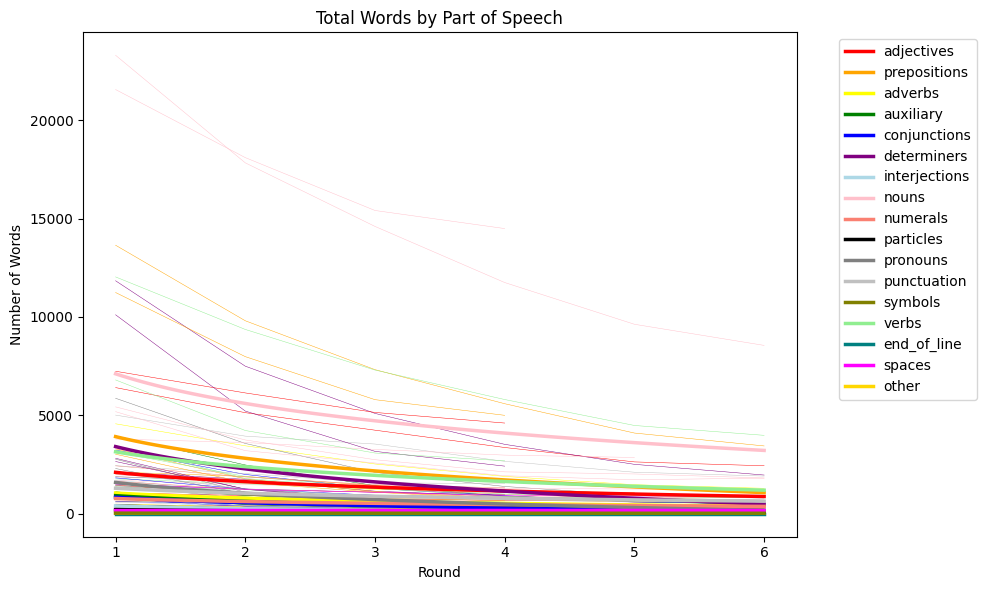

In [ ]:
# Make spaghetti plots for total number of words

import matplotlib.pyplot as plt

fig_02, ax2 = plt.subplots(figsize=(10,6))
for idx in range(len(total_df)):
  ax2.plot(total_df.columns[1:],
           total_df.iloc[idx, 1:],
           color = first_word_dic[total_df.iloc[idx, 0]]["Color"],
           linewidth=0.33,
           label = total_df.iloc[idx, 0]
  )

# Create a mean line
total_mean_df = total_df.groupby("speech_type").mean()


for idx in range(len(total_mean_df)):
  x_data = numpy.array(total_mean_df.columns, dtype=float)
  y_data = numpy.array(total_mean_df.iloc[idx,:], dtype=float)
  coefficients = numpy.polyfit(numpy.log(x_data), y_data, 1)
  slope = coefficients[0]
  y_int = coefficients[1]
  x_dp = numpy.linspace(min(x_data), max(x_data), 100)
  y_dp = numpy.polyval(coefficients, numpy.log(x_dp))
  ax2.plot(x_dp,
           y_dp,
           color = first_word_dic[total_mean_df.index[idx]]["Color"],
           linewidth=2.5,
           label = total_mean_df.index[idx]
           )
handles, labels = ax2.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax2.legend(unique.values(), unique.keys(), bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.set_title("Total Words by Part of Speech")
ax2.set_xlabel("Round")
ax2.set_ylabel("Number of Words")
fig_02.tight_layout()
fig_02.show()
fig_02.savefig("Syntactic Constituents Spaghetti Plot (Total).png")

In [ ]:
# Save dataframes

percentage_df.to_csv("overall_syn_con_perc_v2.csv", index=False)
total_df.to_csv("overall_syn_con_total_v2.csv", index=False)


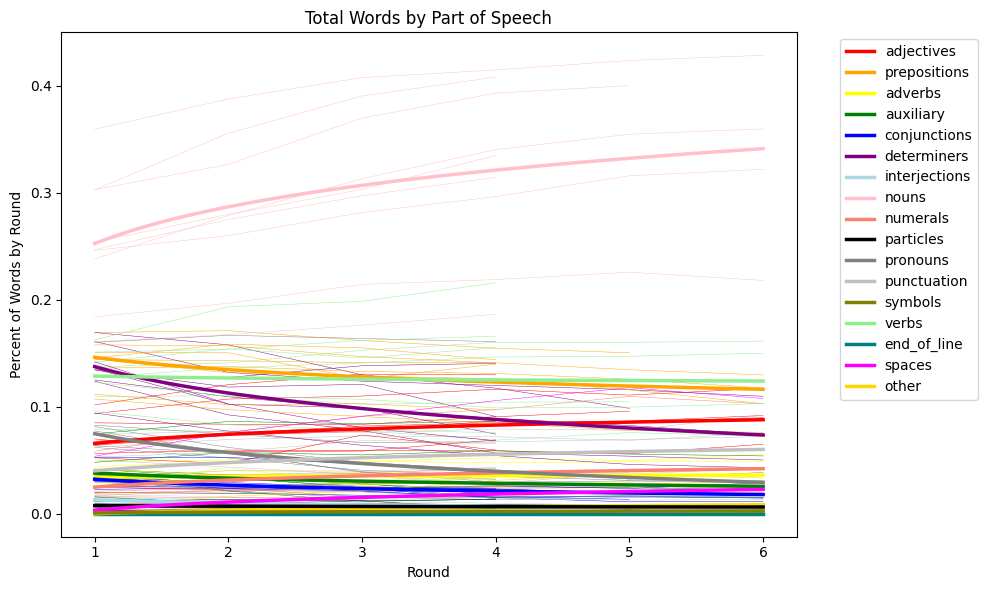

In [ ]:
# Make spaghetti plots for percent of words

fig_03, ax3 = plt.subplots(figsize=(10,6))
for idx in range(len(percentage_df)):
  ax3.plot(percentage_df.columns[1:],
           percentage_df.iloc[idx, 1:],
           color = first_word_dic[percentage_df.iloc[idx, 0]]["Color"],
           linewidth=0.33,
           label = percentage_df.iloc[idx, 0]
  )

percentage_mean_df = percentage_df.groupby("speech_type").mean()

for idx in range(len(percentage_mean_df)):
  x_data = numpy.array(percentage_mean_df.columns, dtype=float)
  y_data = numpy.array(percentage_mean_df.iloc[idx,:], dtype=float)
  coefficients = numpy.polyfit(numpy.log(x_data), y_data, 1)
  slope = coefficients[0]
  y_int = coefficients[1]
  x_dp = numpy.linspace(min(x_data), max(x_data), 100)
  y_dp = numpy.polyval(coefficients, numpy.log(x_dp))
  ax3.plot(x_dp,
           y_dp,
           color = first_word_dic[percentage_mean_df.index[idx]]["Color"],
           linewidth=2.5,
           label = percentage_mean_df.index[idx]
           )
handles, labels = ax3.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax3.legend(unique.values(), unique.keys(), bbox_to_anchor=(1.05, 1), loc='upper left')
ax3.set_title("Total Words by Part of Speech")
ax3.set_xlabel("Round")
ax3.set_ylabel("Percent of Words by Round")
fig_03.tight_layout()
fig_03.show()
fig_03.savefig("Syntactic Constituents Spaghetti Plot (%).png")

In [ ]:
# save mean_df
percentage_mean_df.to_csv("mean_syn_con_perc_v2.csv", index=False)
